In [3]:
!pip install -q timm grad-cam

In [4]:
import os, random, cv2, torch, timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import albumentations as A
from pathlib import Path
from collections import defaultdict
from tqdm.auto import tqdm
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# 1. Global constants for the project
SEED, IMG_SIZE, BATCH_SIZE, NUM_EPOCHS = 42, 224, 32, 15
LR, WEIGHT_DECAY = 1e-4, 1e-4
CLASS_NAMES = ["NORMAL", "PNEUMONIA"]
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}

# 2. Function to ensure deterministic results (reproducibility)
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
# 3. Detect hardware: use NVIDIA GPU if available for 50x faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
# 1. Search for the dataset root path (supports Kaggle and local paths)
KAGGLE_PATH = Path("/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray")
DATASET_ROOT = KAGGLE_PATH if KAGGLE_PATH.exists() else Path("./chest_xray")

# 2. Helper to extract file paths and labels into a DataFrame
def build_split_dataframe(split_name: str) -> pd.DataFrame:
    split_dir = DATASET_ROOT / split_name
    records = []
    for class_name in CLASS_NAMES:
        class_dir = split_dir / class_name
        if not class_dir.exists(): continue
        for img_path in sorted(class_dir.glob("*")):
            if img_path.suffix.lower() in {".jpeg", ".jpg", ".png"}:
                records.append({"label": CLASS_TO_IDX[class_name], "path": str(img_path)})
    return pd.DataFrame(records)

# 3. Merge original folders and create a NEW stratified 85/15 split
# Stratification ensures both sets have the same ratio of sick/healthy patients
train_val_df = pd.concat([build_split_dataframe("train"), build_split_dataframe("val")], ignore_index=True)
test_df = build_split_dataframe("test")
train_df, valid_df = train_test_split(train_val_df, test_size=0.15, stratify=train_val_df["label"], random_state=SEED)

print(f"Data ready: {len(train_df)} Train | {len(valid_df)} Val | {len(test_df)} Test")

Data ready: 4447 Train | 785 Val | 624 Test


In [6]:
# 1. Training transformations: Includes CLAHE for medical contrast enhancement
train_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.5), # Standard clinical contrast booster
    A.RandomBrightnessContrast(p=0.5),
    A.HorizontalFlip(p=0.5), # Teaches AI to recognize lungs regardless of orientation
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=10, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), # ImageNet standards
    ToTensorV2(),
])

# 2. Evaluation transforms (no random changes, just resizing and normalization)
eval_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# 3. Dataset class to load images from disk and apply transforms
class ChestXRayDataset(Dataset):
    def __init__(self, dataframe, transforms=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transforms = transforms
    def __len__(self): return len(self.dataframe)
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        # Load as grayscale then convert to RGB for the pre-trained model
        image = cv2.cvtColor(cv2.imread(row.path, cv2.IMREAD_GRAYSCALE), cv2.COLOR_GRAY2RGB)
        if self.transforms: image = self.transforms(image=image)["image"]
        return image, int(row.label)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [7]:
# 1. Calculate inverse weights for each class
class_counts = train_df["label"].value_counts().sort_index()
class_weights = len(train_df) / (len(CLASS_NAMES) * class_counts)
class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32, device=device)

# 2. WeightedRandomSampler: Ensures the AI sees "Normal" and "Pneumonia" equally
sample_weights = train_df["label"].map(class_weights.to_dict()).values
train_sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# 3. Initialize DataLoaders
train_loader = DataLoader(ChestXRayDataset(train_df, train_transforms), batch_size=BATCH_SIZE, sampler=train_sampler)
valid_loader = DataLoader(ChestXRayDataset(valid_df, eval_transforms), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(ChestXRayDataset(test_df, eval_transforms), batch_size=BATCH_SIZE, shuffle=False)

In [8]:
# 1. Load MobileNetV4 Medium from the 2024 timm library update
# pretrained=True loads features learned from 1 million images
model = timm.create_model("mobilenetv4_conv_medium", pretrained=True, num_classes=2).to(device)

# 2. Function to evaluate the model on the validation set during training
def run_validation(model, loader, criterion):
    model.eval()
    running_loss, all_labels, all_probs = 0.0, [], []
    with torch.no_grad(): # Disable gradient calculation for speed
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(torch.softmax(outputs, dim=1)[:, 1].cpu().numpy())
    
    # Calculate the F1-score: the balance between precision and recall
    val_f1 = f1_score(all_labels, (np.array(all_probs) >= 0.5).astype(int))
    return running_loss / len(loader.dataset), val_f1

model.safetensors:   0%|          | 0.00/39.2M [00:00<?, ?B/s]

In [10]:
import torch.nn as nn

# 1. Loss function: applies the class weights calculated earlier
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
# 2. Optimizer: AdamW is the industry standard for stable training
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
# 3. Scheduler: Smoothly reduces learning rate according to a cosine curve
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
history = defaultdict(list)

print("Starting Training...")
for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward() # Backpropagation
        optimizer.step() # Update weights
        train_loss += loss.item() * images.size(0)
    
    scheduler.step()
    val_loss, val_f1 = run_validation(model, valid_loader, criterion)
    
    # Save statistics for the report plots
    history["train_loss"].append(train_loss/len(train_loader.dataset))
    history["val_loss"].append(val_loss)
    print(f"Epoch {epoch+1} | Train Loss: {history['train_loss'][-1]:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")

Starting Training...


Epoch 1:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 1.0696 | Val Loss: 0.5128 | Val F1: 0.9515


Epoch 2:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 2 | Train Loss: 0.2966 | Val Loss: 0.2217 | Val F1: 0.9565


...

Epoch 13 | Train Loss: 0.0477 | Val Loss: 0.0485 | Val F1: 0.9826


Epoch 14:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 14 | Train Loss: 0.0562 | Val Loss: 0.0595 | Val F1: 0.9790


Epoch 15:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 15 | Train Loss: 0.0566 | Val Loss: 0.0430 | Val F1: 0.9843



--- 2024 MOBILENET-V4 CLINICAL REPORT ---
              precision    recall  f1-score   support

      NORMAL       0.98      0.70      0.81       234
   PNEUMONIA       0.84      0.99      0.91       390

    accuracy                           0.88       624
   macro avg       0.91      0.84      0.86       624
weighted avg       0.89      0.88      0.87       624



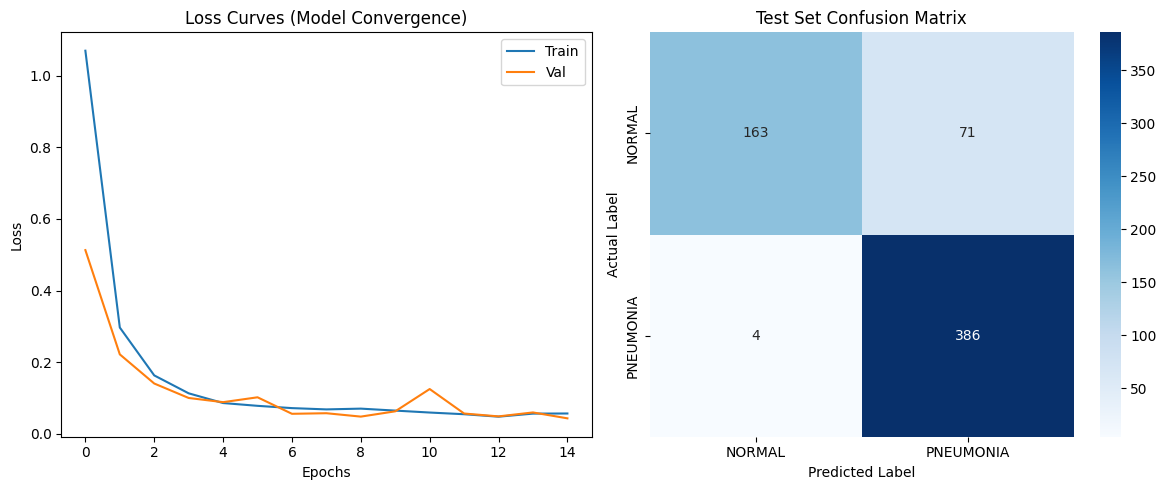

In [13]:
model.eval()
test_labels, test_probs = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        test_labels.extend(labels.numpy())
        test_probs.extend(torch.softmax(outputs, dim=1)[:, 1].cpu().numpy())

test_labels, test_probs = np.array(test_labels), np.array(test_probs)
test_preds = (test_probs >= 0.5).astype(int)

# 1. Generate full classification report (Accuracy, Precision, Recall, F1)
print("\n--- 2024 MOBILENET-V4 CLINICAL REPORT ---")
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

# 2. Plotting the results for the project document
plt.figure(figsize=(12, 5))

# Graph A: Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.title("Loss Curves (Model Convergence)")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()

# Graph B: Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Test Set Confusion Matrix")
plt.xlabel("Predicted Label"); plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

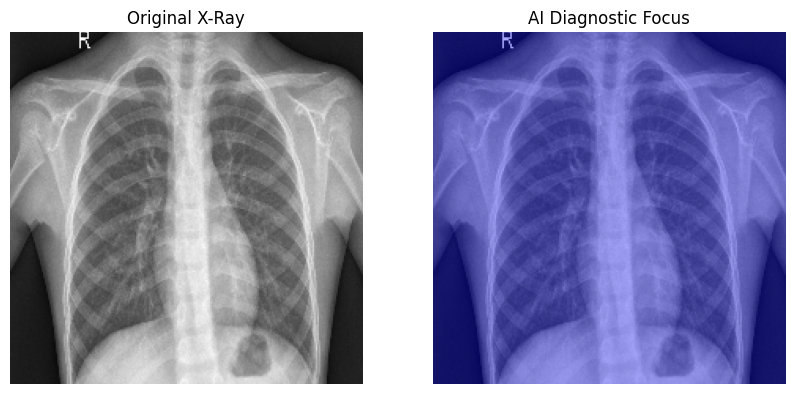

In [14]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# 1. Prepare a single image from the test set
images, labels = next(iter(test_loader))
input_tensor = images[0].unsqueeze(0).to(device)

# 2. Point to the last layer of the MobileNetV4 architecture
# For MobileNetV4, the final feature layer is usually 'conv_head'
target_layers = [model.conv_head]

# 3. Generate the Heatmap
cam = GradCAM(model=model, target_layers=target_layers)
grayscale_cam = cam(input_tensor=input_tensor)[0, :]

# 4. Prepare the original image for visualization
img_orig = images[0].permute(1, 2, 0).cpu().numpy()
# Un-normalize the image back to 0-1 range
img_orig = np.clip(img_orig * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)

# 5. Overlay the heatmap
visualization = show_cam_on_image(img_orig, grayscale_cam, use_rgb=True)

# 6. Display the result
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img_orig); plt.title("Original X-Ray"); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(visualization); plt.title("AI Diagnostic Focus"); plt.axis('off')
plt.show()